# EDA - Email Spam Classification

In [23]:
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Final

In [ ]:
DATASET_PATH: Final[Path] = Path("../data/email-spam-classification-dataset.csv")

LABEL_COL: Final[str] = "label"
CATEGORY_COL: Final[str] = "category"
TEXT_COL: Final[str] = "text"

## Load Dataset

In [36]:
df = pd.read_csv(DATASET_PATH)
df[CATEGORY_COL] = df[LABEL_COL].map({0: "Ham", 1: "Spam"})

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Duplicates: {df.duplicated().sum()}")

print(f"\nNull values per column:\n{df.isnull().sum()}")

df.head()

Shape: (83448, 3)
Columns: ['label', 'text', 'category']
Duplicates: 0

Null values per column:
label       0
text        0
category    0
dtype: int64


,label,text,category
0,1,ounce feather bowl hummingbird opec moment ala...,Spam
1,1,wulvob get your medircations online qnb ikud v...,Spam
2,0,computer connection from cnn com wednesday es...,Ham
3,1,university degree obtain a prosperous future m...,Spam
4,0,thanks for all your answers guys i know i shou...,Ham


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   label     83448 non-null  int64
 1   text      83448 non-null  str  
 2   category  83448 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.9 MB


## Class Distribution

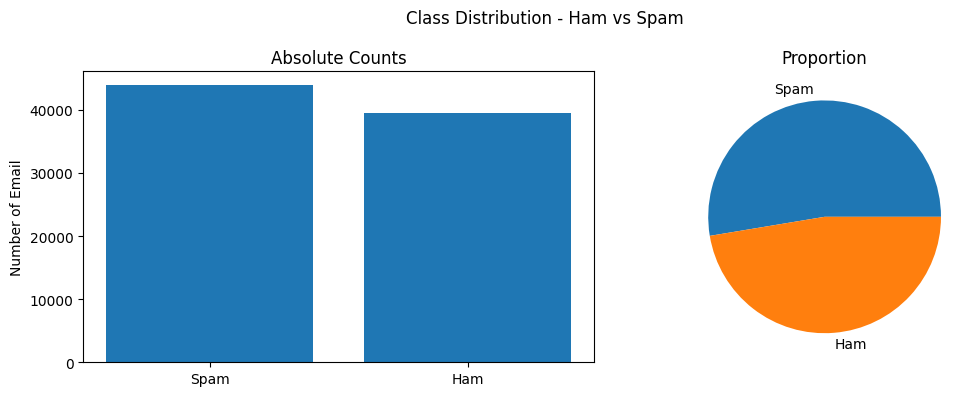

In [37]:
counts = df[CATEGORY_COL].value_counts()
props = df[CATEGORY_COL].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(
    counts.index,
    counts.values,
)
axes[0].set_title("Absolute Counts")
axes[0].set_ylabel("Number of Email")


axes[1].pie(props.values, labels=props.index)
axes[1].set_title("Proportion")

fig.suptitle("Class Distribution - Ham vs Spam")
plt.tight_layout()
plt.show()